In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# read the csv file
data = pd.read_csv('loans.csv')
# display the first 5 rows of the data
data.head()


,Loan ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies
0,14dd8831-6af5-400b-83ec-68e61888a048,Fully Paid,445412.0,Short Term,709.0,1167493.0,Home Mortgage,Home Improvements,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0
1,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,Fully Paid,99999999.0,Short Term,741.0,2231892.0,Own Home,Debt Consolidation,29200.53,14.9,18.0,1.0,297996.0,750090.0,0.0
2,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,Fully Paid,347666.0,Long Term,721.0,806949.0,Own Home,Debt Consolidation,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0
3,89d8cb0c-e5c2-4f54-b056-48a645c543dd,Charged Off,206602.0,Short Term,7290.0,896857.0,Home Mortgage,Debt Consolidation,16367.74,17.3,6.0,0.0,215308.0,272448.0,0.0
4,273581de-85d8-4332-81a5-19b04ce68666,Fully Paid,217646.0,Short Term,730.0,1184194.0,Home Mortgage,Debt Consolidation,10855.08,19.6,13.0,1.0,122170.0,272052.0,1.0


In [2]:
# Remove unrealistic values of current loan amount - loan amount should be less than  99999999
data = data[data['Current Loan Amount'] < 99999999]
data 

,Loan ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies
0,14dd8831-6af5-400b-83ec-68e61888a048,Fully Paid,445412.0,Short Term,709.0,1167493.0,Home Mortgage,Home Improvements,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0
2,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,Fully Paid,347666.0,Long Term,721.0,806949.0,Own Home,Debt Consolidation,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0
3,89d8cb0c-e5c2-4f54-b056-48a645c543dd,Charged Off,206602.0,Short Term,7290.0,896857.0,Home Mortgage,Debt Consolidation,16367.74,17.3,6.0,0.0,215308.0,272448.0,0.0
4,273581de-85d8-4332-81a5-19b04ce68666,Fully Paid,217646.0,Short Term,730.0,1184194.0,Home Mortgage,Debt Consolidation,10855.08,19.6,13.0,1.0,122170.0,272052.0,1.0
5,8af915d9-9e91-44a0-b5a2-564a45c12089,Fully Paid,548746.0,Short Term,678.0,2559110.0,Rent,Debt Consolidation,18660.28,22.6,4.0,0.0,437171.0,555038.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70313,3b2a09bb-3467-4d2f-bd8f-260fdc5760be,Fully Paid,179454.0,Short Term,708.0,1356068.0,Home Mortgage,Debt Consolidation,22318.54,22.7,25.0,0.0,387410.0,1705616.0,0.0
70314,38530a21-5a57-47f5-9aaa-b4475b1db345,Fully Paid,781022.0,Short Term,741.0,2582404.0,Home Mortgage,Debt Consolidation,51648.08,26.3,25.0,0.0,669180.0,2299198.0,0.0
70316,8506a4e9-af7d-47d2-a1bf-7ea2c41858f0,Fully Paid,210584.0,Short Term,719.0,783389.0,Home Mortgage,Other,3727.61,17.4,6.0,0.0,456.0,259160.0,0.0
70318,e1cb4050-eff5-4bdb-a1b0-aabd3f7eaac7,Fully Paid,103136.0,Short Term,742.0,1150545.0,Rent,Debt Consolidation,7315.57,18.8,12.0,1.0,109554.0,537548.0,1.0


In [3]:
# Figure out which loans have the highest Current Credit Balance using nlargest() function
data.nlargest(5, 'Current Credit Balance')




,Loan ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies
12459,c194cb68-1c4d-4bba-8433-98cf4e0f357d,Charged Off,762850.0,Short Term,7320.0,7529320.0,Home Mortgage,other,205801.35,32.5,28.0,0.0,32878968.0,98627914.0,0.0
34554,c4c387b5-7708-4f96-bf0a-6b23a60f196c,Fully Paid,761684.0,Long Term,691.0,4698700.0,Home Mortgage,Debt Consolidation,124907.14,36.5,27.0,0.0,12986956.0,20238944.0,0.0
49789,007ebd31-1453-4d04-97f4-97737e01c608,Fully Paid,235312.0,Long Term,724.0,6580802.0,Own Home,Debt Consolidation,120647.91,33.1,10.0,0.0,12746397.0,14598408.0,0.0
68019,3dbc3b41-ad17-4b11-aa78-246c3afdc191,Fully Paid,773784.0,Long Term,710.0,5155137.0,Home Mortgage,Debt Consolidation,101813.97,22.9,12.0,0.0,11796435.0,16677694.0,0.0
38748,9dfa56f4-ced5-4cce-ad91-076068c1910b,Fully Paid,760298.0,Short Term,733.0,8629876.0,Home Mortgage,Home Improvements,87017.91,24.1,22.0,0.0,11361924.0,20333720.0,0.0


In [4]:
# figure out which loan has the smallest Annual Income using nsmallest() function
data.nsmallest(5, 'Annual Income')


,Loan ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies
48729,fdda52f3-bbfa-45da-80b5-2bd9b68638ed,Charged Off,30448.0,Short Term,736.0,76627.0,Rent,Debt Consolidation,845.50,9.5,8.0,0.0,28177.0,147598.0,0.0
38169,9ed28b3a-c3a9-4ae4-93e6-3de7ff42f64e,Fully Paid,61490.0,Short Term,662.0,81092.0,Rent,Educational Expenses,0.00,11.0,6.0,0.0,0.0,0.0,0.0
7624,241e16a3-c198-4d8e-8dad-c927fd7c7d24,Fully Paid,34342.0,Short Term,715.0,111245.0,Own Home,Other,463.60,29.7,3.0,0.0,6840.0,264044.0,0.0
18719,1596dd1e-d8ba-45eb-b4a8-ee75736b66b6,Fully Paid,47894.0,Short Term,688.0,130150.0,Own Home,Other,2971.41,21.3,3.0,0.0,100510.0,191730.0,0.0
22489,c28d26b0-a805-4e71-b389-f9fc1c9d8bb2,Fully Paid,46860.0,Short Term,714.0,134881.0,Rent,Debt Consolidation,1641.22,6.0,4.0,0.0,43491.0,89298.0,0.0


In [5]:
# min, max and mean of the current loan amount usinf describe() function
# Make as a dataframe
# we need to switch pandas to the decimal format of 2 decimal places

data.describe().loc[['min', 'max', 'mean'], ['Current Loan Amount']].round(2)

,Current Loan Amount
min,15422.0
max,789250.0
mean,312122.3


In [6]:
# Create a new column as "Actual Anual Income" and calculate it using follwing formula
# Actual Annual Income = Annual Income - 12 * Monthly Debt
data['Actual Annual Income'] = data['Annual Income'] - 12 * data['Monthly Debt']
data.head()

,Loan ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Actual Annual Income
0,14dd8831-6af5-400b-83ec-68e61888a048,Fully Paid,445412.0,Short Term,709.0,1167493.0,Home Mortgage,Home Improvements,5214.74,17.2,6.0,1.0,228190.0,416746.0,1.0,1104916.12
2,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,Fully Paid,347666.0,Long Term,721.0,806949.0,Own Home,Debt Consolidation,8741.90,12.0,9.0,0.0,256329.0,386958.0,0.0,702046.20
3,89d8cb0c-e5c2-4f54-b056-48a645c543dd,Charged Off,206602.0,Short Term,7290.0,896857.0,Home Mortgage,Debt Consolidation,16367.74,17.3,6.0,0.0,215308.0,272448.0,0.0,700444.12
4,273581de-85d8-4332-81a5-19b04ce68666,Fully Paid,217646.0,Short Term,730.0,1184194.0,Home Mortgage,Debt Consolidation,10855.08,19.6,13.0,1.0,122170.0,272052.0,1.0,1053933.04
5,8af915d9-9e91-44a0-b5a2-564a45c12089,Fully Paid,548746.0,Short Term,678.0,2559110.0,Rent,Debt Consolidation,18660.28,22.6,4.0,0.0,437171.0,555038.0,0.0,2335186.64


In [7]:
# Figureout how many loans are only "Long term" using value_counts() function
data['Term'].value_counts()





Term
Short Term    42141
Long Term     16752
Name: count, dtype: int64

In [8]:
# Figure out most 3 common lioan purposes using value_counts() function
data['Purpose'].value_counts().head(3).to_frame()

,count
Purpose,
Debt Consolidation,46474
other,3570
Home Improvements,3397


In [9]:
# replace "other" with "Other" in the "Purpose" column for united data
data['Purpose'] = data['Purpose'].replace('other', 'Other')
data['Purpose'].value_counts().head(3).to_frame()

,count
Purpose,
Debt Consolidation,46474
Other,5437
Home Improvements,3397


In [10]:
# study the distribution of "Number of Credit Problems" using value_counts() function
data['Number of Credit Problems'].value_counts().to_frame()

,count
Number of Credit Problems,
0.0,50788
1.0,7014
2.0,753
3.0,216
4.0,72
5.0,33
6.0,10
7.0,5
8.0,2


- **Extreme Right-Skewed Distribution:** The vast majority of individuals in this dataset (over 50,000) have 0.0 credit problems. As the number of credit problems increases, the count drops off significantly.

- **The "Typical" Case:** The mode of this dataset is 0. This suggests that the "average" borrower in this pool is relatively credit-worthy or has not encountered formal credit issues.

In [11]:
# Figure out how many unique "Home Ownership" types are there using unique() function
data['Home Ownership'].unique()


<StringArray>
['Home Mortgage', 'Own Home', 'Rent']
Length: 3, dtype: str

In [12]:
# figure out how many loaners have more than 1 bannkruptcy using value_counts() function
data[data['Bankruptcies'] > 1]['Bankruptcies'].value_counts().to_frame()



,count
Bankruptcies,
2.0,227
3.0,58
4.0,15
5.0,4
6.0,1


In [13]:
# Figure out How many Short Term loans are for Home Improvements
# Fist we need to filter the data for short term loans and home improvement purpose and then we can use value_counts() function to count the number of loans
loan_with_short_term = data[data['Term'] == 'Short Term']

# now we need to filter the data for home improvement purpose and count the number of loans
loan_with_short_term_and_home_improvement = loan_with_short_term[loan_with_short_term['Purpose'] == 'Home Improvements']
loan_with_short_term_and_home_improvement['Term'].value_counts().to_frame()


,count
Term,
Short Term,2324


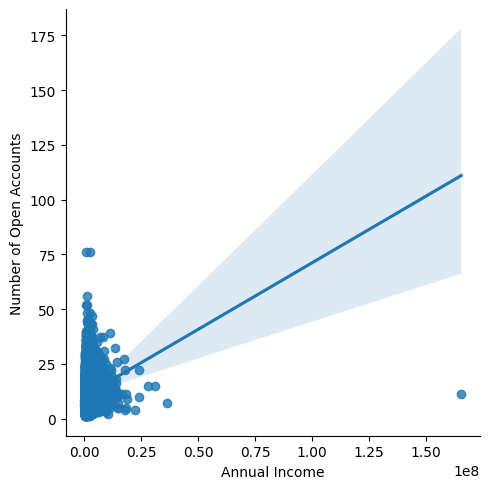

In [14]:
# See the correation between "Annual Income" and "Number of Open Accounts" using scatter plot with linear regression line
sns.lmplot(x = 'Annual Income', y = 'Number of Open Accounts', data = data)
plt.show()




- No real correlation — the relationship is not consistent across all income levels.

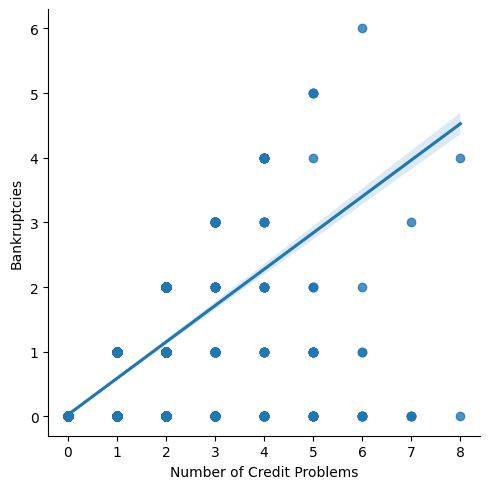

In [15]:
# See the correlation between "Number of Credit Problems" and "Bankruptcies" using scatter plot
sns.lmplot(x = 'Number of Credit Problems', y = 'Bankruptcies', data = data)
plt.show()

- people with more credit problems (late payments, defaults, collections) are much more likely to have filed for bankruptcy.
- Very strong positive correlation.


In [16]:
# Load the new date set "purchases.csv"
data = pd.read_csv('purchases.csv')
data.head()


,Purchase Date,Purchase Order Number,Acquisition Type,Acquisition Method,Department Name,Supplier Name,Item Name,Item Description,Quantity,Unit Price,Total Price,Commodity Title,Class Title,Family Title,Segment Title
0,08/31/2012,4500149558,Other Goods,Formal Competitive,"Corrections and Rehabilitation, Department of",Fresno Produce Inc.,JALAPENO,JALAPENO,40.0,$0.60,24.00,Jalapeno peppers,Peppers,Fresh vegetables,Food Beverage and Tobacco Products
1,10/18/2012,4500156192,Other Goods,Informal Competitive,"Corrections and Rehabilitation, Department of",PETER GIAMMANCO,produce,"red apples, banana,",1.0,$12587.05,12587.05,Ida red apples,Apples,Fresh fruits,Food Beverage and Tobacco Products
2,10/17/2012,4500156124,Other Goods,Fair and Reasonable,Correctional Health Care Services,OSHA Review Inc,magazine,magazine,1.0,$199.00,199.00,Magazines,Printed publications,Printed media,Published Products
3,10/24/2012,S2556056,Other Goods,Informal Competitive,"Parks & Recreation, Department of",Agco Hay LLC,hay,Bale's of rice straw,1000.0,$4.95,4950.00,Hay,Livestock feed,Animal feed,Live Plant and Animal Material and Accessories...
4,11/14/2012,4500159228,Other Goods,Informal Competitive,"Corrections and Rehabilitation, Department of",Prison Industry Authority,COFFEE,INSTANT COFFEE AND BULK,14686.5,$1.00,14686.50,Coffee,Coffee and tea,Beverages,Food Beverage and Tobacco Products


In [17]:
# figureout the total price of the purchase order number of 018H2015
po_018H2015 = data[data['Purchase Order Number'] == "018H2015"]

# Get the row count of it
row_count = len(po_018H2015)

# Get the sum of the total price related to the specified purchase order number
total_price = po_018H2015['Total Price'].sum()

print(f"Total Price:{total_price:,.2f}")
print(f"Row Count: {row_count}")

Total Price:1,245.04
Row Count: 14


In [18]:
#  item name and description of the purchased item with the Purchase Order Number 3176273
po_3176273 = data[data['Purchase Order Number'] == "3176273"]
item_details = po_3176273[['Item Name', 'Item Description']]
item_details



,Item Name,Item Description
103,PC Desktop,HP Prodesk 600


In [19]:
#  How many occasions (rows) of purchase data happened during the year 2013
# First we convert Purchase Date in to datetime object
data['Purchase Date'] = pd.to_datetime(data['Purchase Date'])
purchases_2013 = data[data['Purchase Date'].dt.year == 2013]
print(f'Purchases in 2013: {len(purchases_2013)}')

Purchases in 2013: 33907


In [20]:
#  5 most common Departments in the data
top_5_departments = data['Department Name'].value_counts().head(5)
top_5_departments.to_frame()


,count
Department Name,
"Corrections and Rehabilitation, Department of",10858
Correctional Health Care Services,6591
"Water Resources, Department of",4566
"Forestry and Fire Protection, Department of",4513
"State Hospitals, Department of",4258


In [21]:
#  3 Departments using most money
# Group by department name and calculate each total price and sort them in to descending order
top_3_spenders = data.groupby('Department Name')['Total Price'].sum().sort_values(ascending = False).head(3)
top_3_spenders.to_frame()

,Total Price
Department Name,
"Health Care Services, Department of",2.186685e+10
"Public Health, Department of",2.747346e+09
"Social Services, Department of",1.291192e+09


In [22]:
# Replace the $-sign in the Unit Price –column with an empty string, and convert the value to float 
# We use regex = False, because to treat $ as a normal character
data['Unit Price'] = data['Unit Price'].str.replace("$", "", regex = False).astype(float)

In [23]:
# IT Goods and had the total price of more than 50000 dollars
it_goods = data[(data['Acquisition Type'] == 'IT Goods') & (data['Total Price'] > 50000)]
print(f'Number of IT Goods purchased over 50,000$: {len(it_goods)}')  

Number of IT Goods purchased over 50,000$: 698


In [24]:
# How many of the purchases have anything to do with IT?  (IT Goods, IT Services, IT Telecommunications
it_categories = ['IT Goods', 'IT Services', 'IT Telecommunications']
it_related = data[data['Acquisition Type'].isin(it_categories)]
print(f'Total IT-Related Purchases: {len(it_related)}')

Total IT-Related Purchases: 9517


In [25]:
# Filter out purchases that have a Total Price of 0 or less
df_filtered = data[data['Total Price'] > 0]

# Calculate Sum and Mean by Acquisition Type
sum_by_acq = df_filtered.groupby('Acquisition Type')['Total Price'].sum()
mean_by_acq = df_filtered.groupby('Acquisition Type')['Total Price'].mean()
# We can obtain the top two recored of each for the analysis
top_2_sums = sum_by_acq.sort_values(ascending = False).head(2)
top_2_mean = mean_by_acq.sort_values(ascending = False).head(2)

print(top_2_sums.to_frame())
print(top_2_mean.to_frame())

                   Total Price
Acquisition Type              
Other Services    3.055937e+10
IT Services       1.156961e+09
                   Total Price
Acquisition Type              
Other Services    2.484299e+06
IT Services       6.849976e+05


- Other Services and IT Services have top 2 largest sums and means aquisition

In [26]:
# Load the dataset 
data = pd.read_csv('salaries_india.csv')
data.head()

,Row ID,Company Name,Rating,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,79417,Unacademy,Good,Android Developer,2046000.0,3,Bangalore,Full Time,Mobile
1,79419,Appoids Tech Solutions,Good,Android Developer,1227600.0,3,Bangalore,Full Time,Mobile
2,79424,Endeavour Software Technologies,Good,Android Developer,1227600.0,3,Bangalore,Full Time,Mobile
3,79427,Wibmo,Good,Android Developer,1841400.0,2,Bangalore,Full Time,Mobile
4,79429,Bookmyshow,Good,Android Developer,1227600.0,2,Bangalore,Full Time,Mobile


In [27]:
# Remove unnecessary columns
data = data.drop(columns = ['Row ID', 'Job Title'])
data.head()

,Company Name,Rating,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,Unacademy,Good,2046000.0,3,Bangalore,Full Time,Mobile
1,Appoids Tech Solutions,Good,1227600.0,3,Bangalore,Full Time,Mobile
2,Endeavour Software Technologies,Good,1227600.0,3,Bangalore,Full Time,Mobile
3,Wibmo,Good,1841400.0,2,Bangalore,Full Time,Mobile
4,Bookmyshow,Good,1227600.0,2,Bangalore,Full Time,Mobile


### Which high salaries can be considered as outliers

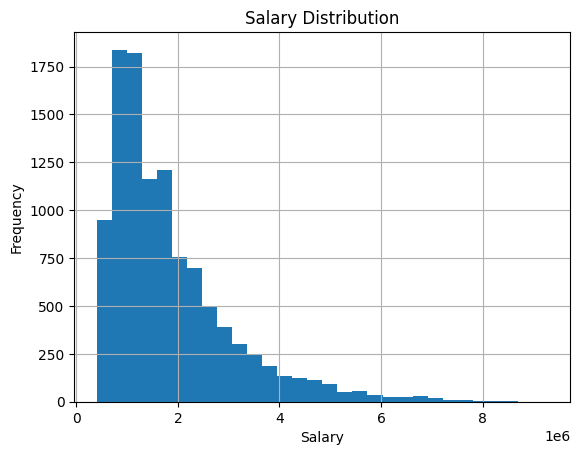

In [28]:
# Check the distribution
data["Salary"].hist(bins = 30)
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution")
plt.show()


In [29]:
#Find the 10 largest salaries
highest_salaries = data.nlargest(10, "Salary")
highest_salaries


,Company Name,Rating,Salary,Salaries Reported,Location,Employment Status,Job Roles
6585,Observe.AI,Excellent,9284422.5,2,Bangalore,Full Time,Full stack
6561,SensAi Technologies,Excellent,8644117.5,1,Bangalore,Full Time,Full stack
8526,Uniify,Excellent,8421043.5,1,Hyderabad,Full Time,Full stack
8229,Planful,Excellent,8109153.0,1,Hyderabad,Full Time,Full stack
8430,Planful,Excellent,8109153.0,1,Hyderabad,Full Time,Full stack
6575,Amazon,Good,8010090.0,3,Bangalore,Full Time,Full stack
6581,KredX,Good,8010090.0,1,Bangalore,Full Time,Full stack
6583,NetApp,Good,8010090.0,1,Bangalore,Full Time,Full stack
6584,ShareChat,Good,8010090.0,2,Bangalore,Full Time,Full stack
6542,Aconex,Excellent,8003812.5,1,Bangalore,Full Time,Full stack


In [30]:
#Frequency of each salary values
print(data["Salary"].value_counts().sort_index(ascending=False).head(20))

Salary
9284422.5     1
8644117.5     1
8421043.5     1
8109153.0     2
8010090.0     4
8003812.5     2
7803378.0     1
7797262.5     1
7733880.0     5
7683660.0     1
7534296.0     2
7457670.0     3
7265214.0     7
7181460.0    10
7173481.5     3
7043355.0     2
6996132.0     4
6905250.0     6
6877350.0     1
6861591.0     1
Name: count, dtype: int64


In [31]:
#FInd a possible cutoff salary
print("Above 5,000,000:", (data["Salary"] > 5000000).sum())
print("Above 6,000,000:", (data["Salary"] > 6000000).sum())
print("Above 7,000,000:", (data["Salary"] > 7000000).sum())
print("Above 8,000,000:", (data["Salary"] > 8000000).sum())

Above 5,000,000: 315
Above 6,000,000: 133
Above 7,000,000: 46
Above 8,000,000: 11


#### A reasonable decision based on examining the histogram and highest values would be to consider salaries above 7,000,000 as outliers

In [32]:
# Remove the Outliers using conditional filtering
data = data[data["Salary"]<= 7000000]
data

,Company Name,Rating,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,Unacademy,Good,2046000.0,3,Bangalore,Full Time,Mobile
1,Appoids Tech Solutions,Good,1227600.0,3,Bangalore,Full Time,Mobile
2,Endeavour Software Technologies,Good,1227600.0,3,Bangalore,Full Time,Mobile
3,Wibmo,Good,1841400.0,2,Bangalore,Full Time,Mobile
4,Bookmyshow,Good,1227600.0,2,Bangalore,Full Time,Mobile
...,...,...,...,...,...,...,...
10782,Full Time Soluções em Serviços Financeiros,Good,2406096.0,1,Bangalore,Full Time,Web
10783,SwervePoint,Good,1227600.0,1,Bangalore,Full Time,Web
10784,rtCamp,Good,1432200.0,1,Bangalore,Full Time,Web
10785,Blu Ocean Innovations,Excellent,967572.0,1,Bangalore,Intern,Web


In [33]:
# Convert "Employment Staus" in to Binary variable using LabelEncorder
data["Employment Status"] = LabelEncoder().fit_transform(data["Employment Status"])
data["Employment Status"].value_counts()

Employment Status
0    10176
1      565
Name: count, dtype: int64

In [34]:
#Handle "Rating" as an ordinal variable using categorical maping
rating_map = {
     "Bad": 1,
    "Poor": 2,
    "Average": 3,
    "Good": 4,
    "Excellent": 5
}
data["Rating"] = data["Rating"].map(rating_map)
data["Rating"].value_counts()

Rating
4    8200
5    1285
3    1154
2      78
1      24
Name: count, dtype: int64

In [35]:
#Handle "Job Roles" and "Location" as NOMINAL categories (OneHotEncoder) - For this we can use .get_dummies()
data = pd.get_dummies(data, columns=["Job Roles","Location"], dtype=int)
data.head()


,Company Name,Rating,Salary,Salaries Reported,Employment Status,Job Roles_Backend,Job Roles_Full stack,Job Roles_Mobile,Job Roles_Web,Location_Bangalore,Location_Chennai,Location_Hyderabad,Location_New Delhi,Location_Pune
0,Unacademy,4,2046000.0,3,0,0,0,1,0,1,0,0,0,0
1,Appoids Tech Solutions,4,1227600.0,3,0,0,0,1,0,1,0,0,0,0
2,Endeavour Software Technologies,4,1227600.0,3,0,0,0,1,0,1,0,0,0,0
3,Wibmo,4,1841400.0,2,0,0,0,1,0,1,0,0,0,0
4,Bookmyshow,4,1227600.0,2,0,0,0,1,0,1,0,0,0,0


In [36]:
# Analyze the correlation matrix from  the point of view of Salary 


corr_matrix = data.corr(numeric_only=True)
corr_matrix


,Rating,Salary,Salaries Reported,Employment Status,Job Roles_Backend,Job Roles_Full stack,Job Roles_Mobile,Job Roles_Web,Location_Bangalore,Location_Chennai,Location_Hyderabad,Location_New Delhi,Location_Pune
Rating,1.000000,0.190004,-0.007101,0.015160,0.006604,-0.009297,-0.006285,0.013473,-0.015929,0.003062,0.001370,0.017116,-0.002149
Salary,0.190004,1.000000,0.084699,-0.079938,-0.057783,0.262089,-0.169412,-0.103345,0.279919,-0.183853,0.166125,-0.258305,-0.128378
Salaries Reported,-0.007101,0.084699,1.000000,0.000082,-0.063725,0.144789,-0.069481,-0.047820,0.045767,-0.025201,-0.006444,-0.009221,-0.027043
Employment Status,0.015160,-0.079938,0.000082,1.000000,-0.075425,0.168613,-0.092270,-0.039874,0.018894,-0.027278,-0.014897,0.021273,-0.011941
Job Roles_Backend,0.006604,-0.057783,-0.063725,-0.075425,1.000000,-0.456967,-0.289794,-0.203547,0.084102,0.145181,0.088549,-0.179531,-0.153592
Job Roles_Full stack,-0.009297,0.262089,0.144789,0.168613,-0.456967,1.000000,-0.465720,-0.327114,-0.176716,-0.030172,0.066242,0.065375,0.140600
Job Roles_Mobile,-0.006285,-0.169412,-0.069481,-0.092270,-0.289794,-0.465720,1.000000,-0.207446,0.019210,-0.094837,-0.110517,0.164983,-0.013879
Job Roles_Web,0.013473,-0.103345,-0.047820,-0.039874,-0.203547,-0.327114,-0.207446,1.000000,0.133080,-0.016749,-0.069418,-0.080982,0.000364
Location_Bangalore,-0.015929,0.279919,0.045767,0.018894,0.084102,-0.176716,0.019210,0.133080,1.000000,-0.277635,-0.383939,-0.413711,-0.276684
Location_Chennai,0.003062,-0.183853,-0.025201,-0.027278,0.145181,-0.030172,-0.094837,-0.016749,-0.277635,1.000000,-0.164846,-0.177629,-0.118795


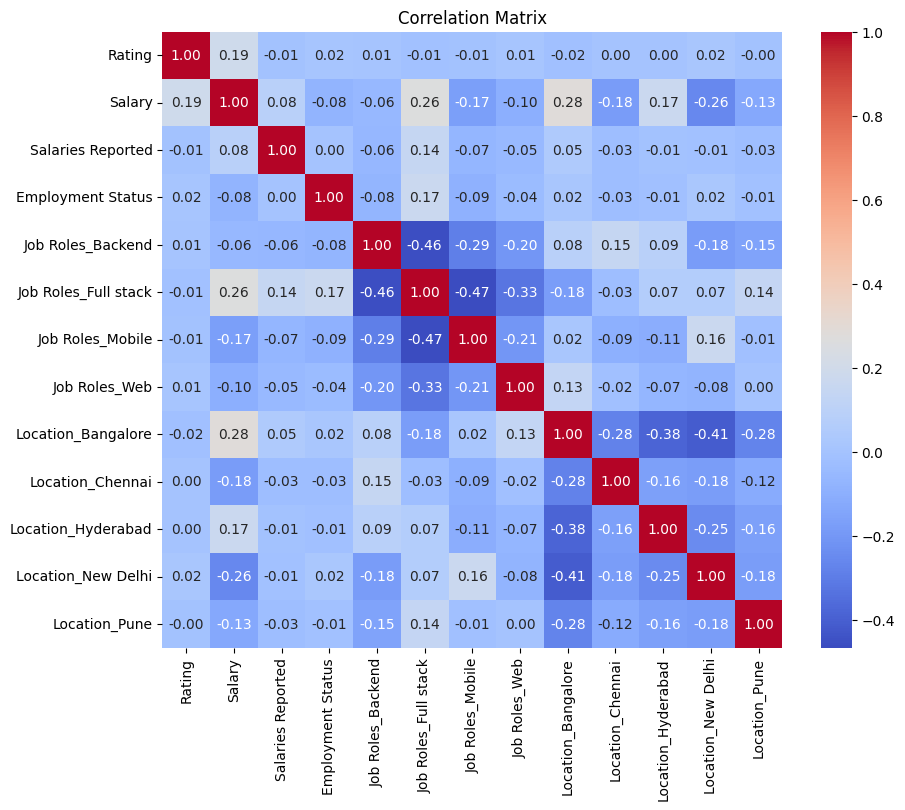

In [37]:
#For better understanding we can use heatmap for the visualize the correlation
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [38]:
# Find which variables are most correlated with Salary
salary_corr = corr_matrix["Salary"].sort_values(ascending=False)
salary_corr

Salary                  1.000000
Location_Bangalore      0.279919
Job Roles_Full stack    0.262089
Rating                  0.190004
Location_Hyderabad      0.166125
Salaries Reported       0.084699
Job Roles_Backend      -0.057783
Employment Status      -0.079938
Job Roles_Web          -0.103345
Location_Pune          -0.128378
Job Roles_Mobile       -0.169412
Location_Chennai       -0.183853
Location_New Delhi     -0.258305
Name: Salary, dtype: float64

#### Based on the correlation the location has a big impact for the Salary, among them "Location_Bangolare" showed a positive correlation. So salaries are generally higher for observations associated with Bangalore compared with the reference location/category


In [39]:
# See the correlation using Spearman
spearman_corr = data.corr(method='spearman', numeric_only= True)
print(spearman_corr["Salary"].sort_values(ascending=False))


Salary                  1.000000
Location_Bangalore      0.332882
Job Roles_Full stack    0.285178
Rating                  0.222346
Location_Hyderabad      0.178285
Salaries Reported       0.136345
Job Roles_Backend      -0.052417
Employment Status      -0.066650
Job Roles_Web          -0.105042
Location_Pune          -0.132741
Job Roles_Mobile       -0.200567
Location_Chennai       -0.217897
Location_New Delhi     -0.304392
Name: Salary, dtype: float64


#### The important conclusion remains similar: location, job role and rating appear to be the most relevant variables associated with salary.

In [40]:
# Calculate the quantiles
q25 = data["Salary"].quantile(0.25)
q50 = data["Salary"].quantile(0.50)
q75 = data["Salary"].quantile(0.75)

print("25%", q25)
print("50%", q50)
print("75%", q75)


25% 996600.0
50% 1432200.0
75% 2295200.0


In [41]:
# We can split the data into parts using qcut() - split the data into equal-sized quantile bins
data["Salary_Category"] = pd.qcut(data["Salary"], q=4, labels=["Bottom 25%","Below Average","Above Average", "Top 25%"])
data.head()

,Company Name,Rating,Salary,Salaries Reported,Employment Status,Job Roles_Backend,Job Roles_Full stack,Job Roles_Mobile,Job Roles_Web,Location_Bangalore,Location_Chennai,Location_Hyderabad,Location_New Delhi,Location_Pune,Salary_Category
0,Unacademy,4,2046000.0,3,0,0,0,1,0,1,0,0,0,0,Above Average
1,Appoids Tech Solutions,4,1227600.0,3,0,0,0,1,0,1,0,0,0,0,Below Average
2,Endeavour Software Technologies,4,1227600.0,3,0,0,0,1,0,1,0,0,0,0,Below Average
3,Wibmo,4,1841400.0,2,0,0,0,1,0,1,0,0,0,0,Above Average
4,Bookmyshow,4,1227600.0,2,0,0,0,1,0,1,0,0,0,0,Below Average


In [42]:
# Find the salary ranges in the category
salary_ranges = data.groupby("Salary_Category")["Salary"].agg(["min","max","count"])
salary_ranges

,min,max,count
Salary_Category,,,
Bottom 25%,406080.0,996600.0,2781
Below Average,996960.0,1432200.0,2636
Above Average,1435104.0,2295200.0,2640
Top 25%,2296166.4,6996132.0,2684


In [43]:
# Do the correlation based on quantile groups
data.columns

Index(['Company Name', 'Rating', 'Salary', 'Salaries Reported',
       'Employment Status', 'Job Roles_Backend', 'Job Roles_Full stack',
       'Job Roles_Mobile', 'Job Roles_Web', 'Location_Bangalore',
       'Location_Chennai', 'Location_Hyderabad', 'Location_New Delhi',
       'Location_Pune', 'Salary_Category'],
      dtype='str')

In [44]:
# Numerical columns are worth for corelation
numeric_cols = ["Rating", "Salary", "Salaries Reported"]

#We can also use one-hot encorded columns for correlation
job_role_cols = ["Job Roles_Backend", "Job Roles_Full stack", "Job Roles_Mobile", "Job Roles_Web"]
location_cols = ["Location_Bangalore", "Location_Chennai", "Location_Hyderabad", 
                  "Location_New Delhi", "Location_Pune"]

# Correlation for numerical fields
corr_numerical_cols = data.groupby("Salary_Category")[numeric_cols].corr()
corr_numerical_cols

Rating    Salary  Salaries Reported
Salary_Category                                                         
Bottom 25%      Rating             1.000000  0.239672          -0.006207
                Salary             0.239672  1.000000           0.051127
                Salaries Reported -0.006207  0.051127           1.000000
Below Average   Rating             1.000000  0.097318          -0.060113
                Salary             0.097318  1.000000           0.033268
                Salaries Reported -0.060113  0.033268           1.000000
Above Average   Rating             1.000000  0.027155          -0.041201
                Salary             0.027155  1.000000          -0.015411
                Salaries Reported -0.041201 -0.015411           1.000000
Top 25%         Rating             1.000000  0.111282          -0.027354
                Salary             0.111282  1.000000           0.027407
                Salaries Reported -0.027354  0.027407           1.000000

In [45]:
#Find the propotion of each job role than correlation based on the role distribution with mean
role_distribution = data.groupby("Salary_Category")[job_role_cols].mean()
role_distribution

,Job Roles_Backend,Job Roles_Full stack,Job Roles_Mobile,Job Roles_Web
Salary_Category,,,,
Bottom 25%,0.229414,0.268249,0.349874,0.152463
Below Average,0.276935,0.302731,0.246586,0.173748
Above Average,0.193182,0.532955,0.170076,0.103788
Top 25%,0.186289,0.595007,0.140462,0.078241


In [46]:
# we can do the same logic for the location distribution
location_distribution = data.groupby("Salary_Category")[location_cols].mean()
location_distribution


,Location_Bangalore,Location_Chennai,Location_Hyderabad,Location_New Delhi,Location_Pune
Salary_Category,,,,,
Bottom 25%,0.113269,0.212154,0.101402,0.406688,0.166487
Below Average,0.451442,0.094841,0.176404,0.180197,0.097117
Above Average,0.442424,0.081818,0.192045,0.172727,0.110985
Top 25%,0.575633,0.032787,0.275708,0.069300,0.046572


### Conclutions
##### Rating is not a meaningful driver of salary — correlations are weak across every tier. 
##### Location is the strongest driver of salary tier — Bangalore and Hyderabad are associated with higher salaries; New Delhi and Chennai are associated with lower salaries.
##### Job role is the second strong driver — Full Stack roles are heavily concentrated at the top (60% of Top 25% earners), while Mobile and Web roles are concentrated at the bottom.


<small>

# Possible improvements to the dataset

**1. Add years of experience.**
Salary is likely strongly affected by experience, but this information is missing from the current dataset.

**2. Add education level.**
Education may have some relationship with salary and could help explain differences between employees.

**3. Add company size.**
Large technology companies may offer different salaries from small firms.

**4. Add industry/company sector.**
Different sectors can have substantially different salary levels.

**5. The dataset only covers selected Indian cities and data-engineering/related roles.**
Therefore, the conclusions cannot be generalized to salaries across all of India or the entire world.

**6. The dataset contains Company Name and Job Title, but these variables require more sophisticated processing.**
Simply converting their names into numbers would produce misleading correlations.

</small>

In [65]:
# Inspect how many duplicates rows there are
df = pd.read_csv('furniture.csv')
print("Number of Duplicated rows:")
print(df.duplicated().sum())

Number of Duplicated rows:
110


In [66]:
# Remove duplicate rows
df = df.drop_duplicates()
df

,brand,category,material,delivery_days,inventory,cost,discount_percentage,price
0,Furneyz,Bed,Plastic,9,105,181.61,27.8,273.18
1,Krude,Chair,Glass,6,192,385.03,26.9,477.82
2,Krude,Table,Metal,2,59,276.74,21.9,379.40
3,Krude,Table,Glass,2,45,281.84,11.0,319.40
4,Krude,Chair,Glass,9,35,69.74,3.2,120.21
...,...,...,...,...,...,...,...,...
2493,Krude,Bed,Glass,8,9,169.68,21.8,387.22
2494,Krude,Desk,Fabric,6,127,277.39,2.8,439.51
2495,Furneyz,Desk,Metal,4,6,405.99,19.8,491.33
2496,LesComfe,Desk,Glass,9,55,172.47,9.5,233.41


In [67]:
# Check how many NAN values are there
print(df.isna().sum())


brand                    0
category                 0
material                 0
delivery_days            0
inventory                0
cost                     0
discount_percentage      0
price                  197
dtype: int64


In [68]:
# Remove all NAN values
df = df.dropna()

# Check after droping the NAN rows
print(df.isna().sum())

brand                  0
category               0
material               0
delivery_days          0
inventory              0
cost                   0
discount_percentage    0
price                  0
dtype: int64


In [69]:
# Replace the NAN values of the price with overall mean price
df = pd.read_csv('furniture.csv')

# Remove duplicates
df  = df.drop_duplicates()

# Calculate the mean price
mean_price = df['price'].mean()
print("Mean Price:", mean_price)

# Replace the missing prices with the mean
df['price'] = df['price'].fillna(mean_price)

# Missing prices after replacements
print(df['price'].isna().sum())



Mean Price: 295.9246936114733
0


In [70]:
# We can calculate the mean price based on the category
df = pd.read_csv('furniture.csv')
df = df.drop_duplicates()

# Calculate the mean price based on category
category_mean = df.groupby('category')['price'].transform('mean')

# Replace the NAN values of the price column with category_mean
df['price'] = df['price'].fillna(category_mean)

print("Missing Prices")
print(df['price'].isna().sum())

Missing Prices
0


In [71]:
#We could also use both category and material
df = pd.read_csv("furniture.csv")

df = df.drop_duplicates()

# Calculate average price for each category and material
category_material_mean = df.groupby(
    ["category", "material"]
)["price"].transform("mean")

# Replace missing prices
df["price"] = df["price"].fillna(category_material_mean)

print("Missing prices:")
print(df["price"].isna().sum())

Missing prices:
0


In [72]:
# The dataset contains both cost and price. We can calculate a typical price/cost multiplier.
df = pd.read_csv('furniture.csv')
df = df.drop_duplicates()

# calculate price / cost
df['profit_multiplier'] = df['price'] / df['cost']
print(df['profit_multiplier'].mean())

1.5903115163336385


In [73]:
# Then calculate the typical multiplier for each category
# For this I analysed the examples from ChatGPT
category_multiplier = df.groupby(
    "category"
)["profit_multiplier"].transform("mean")

# Estimate missing prices
missing_price = df["price"].isna()

df.loc[missing_price, "price"] = (
    df.loc[missing_price, "cost"] *
    category_multiplier[missing_price]
)

print("Missing prices:")
print(df["price"].isna().sum())

Missing prices:
0


In [74]:
# create the delivery_category column
def delivery_category(days):
    if days < 4 :
        return "quick"
    elif days <= 7:
        return "normal"
    else:
        return "slow"

df['delivery_category'] = df['delivery_days'].apply(delivery_category)

# Inspect the distribution of the delivery_category
print(df["delivery_category"].value_counts())

delivery_category
normal    1124
quick      858
slow       516
Name: count, dtype: int64


In [75]:
# For better analysis we can get the percentage
print(df["delivery_category"].value_counts(normalize = True) * 100)

delivery_category
normal    44.995997
quick     34.347478
slow      20.656525
Name: proportion, dtype: float64


In [76]:
df.head()

,brand,category,material,delivery_days,inventory,cost,discount_percentage,price,profit_multiplier,delivery_category
0,Furneyz,Bed,Plastic,9,105,181.61,27.8,273.18,1.504212,slow
1,Krude,Chair,Glass,6,192,385.03,26.9,477.82,1.240994,normal
2,Krude,Table,Metal,2,59,276.74,21.9,379.40,1.370962,quick
3,Krude,Table,Glass,2,45,281.84,11.0,319.40,1.133267,quick
4,Krude,Chair,Glass,9,35,69.74,3.2,120.21,1.723688,slow


In [77]:
# Now we can remove the old "delivery_days" column
df = df.drop(columns = ['delivery_days'])
df.head()

,brand,category,material,inventory,cost,discount_percentage,price,profit_multiplier,delivery_category
0,Furneyz,Bed,Plastic,105,181.61,27.8,273.18,1.504212,slow
1,Krude,Chair,Glass,192,385.03,26.9,477.82,1.240994,normal
2,Krude,Table,Metal,59,276.74,21.9,379.40,1.370962,quick
3,Krude,Table,Glass,45,281.84,11.0,319.40,1.133267,quick
4,Krude,Chair,Glass,35,69.74,3.2,120.21,1.723688,slow


In [78]:
# Calculate the actual discount amount
df["discount_amount"] = (df["price"] * df["discount_percentage"] / 100)

df["discount_amount"] = df["discount_amount"].round(2)

print(df[["price", "discount_percentage", "discount_amount"]].head())

    price  discount_percentage  discount_amount
0  273.18                 27.8            75.94
1  477.82                 26.9           128.53
2  379.40                 21.9            83.09
3  319.40                 11.0            35.13
4  120.21                  3.2             3.85


In [79]:
# Remove the original discount_percentage column 
df = df.drop(columns=["discount_percentage"])
print(df.head())

     brand category material  inventory    cost   price  profit_multiplier  \
0  Furneyz      Bed  Plastic        105  181.61  273.18           1.504212   
1    Krude    Chair    Glass        192  385.03  477.82           1.240994   
2    Krude    Table    Metal         59  276.74  379.40           1.370962   
3    Krude    Table    Glass         45  281.84  319.40           1.133267   
4    Krude    Chair    Glass         35   69.74  120.21           1.723688   

  delivery_category  discount_amount  
0              slow            75.94  
1            normal           128.53  
2             quick            83.09  
3             quick            35.13  
4              slow             3.85  


In [80]:
# To see the corelation of the data we need to use one-hot encorded to convert the nominal category in to numerical values
df = pd.get_dummies(df, columns = ["brand", "category", "material", "delivery_category"], dtype = int)
df.head()


,inventory,cost,price,profit_multiplier,discount_amount,brand_Furneyz,brand_Krude,brand_LesComfe,brand_Ordinaer,category_Bed,...,category_Sofa,category_Table,material_Fabric,material_Glass,material_Metal,material_Plastic,material_Wood,delivery_category_normal,delivery_category_quick,delivery_category_slow
0,105,181.61,273.18,1.504212,75.94,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
1,192,385.03,477.82,1.240994,128.53,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
2,59,276.74,379.40,1.370962,83.09,0,1,0,0,0,...,0,1,0,0,1,0,0,0,1,0
3,45,281.84,319.40,1.133267,35.13,0,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4,35,69.74,120.21,1.723688,3.85,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [81]:
# Then we can see the correlation, how each categoties affect for the selling price
correlation = df.corr(numeric_only = True)
print(correlation['price'].sort_values(ascending = False))

price                       1.000000
cost                        0.915262
discount_amount             0.604341
category_Bed                0.115906
category_Sofa               0.074726
profit_multiplier           0.052129
material_Fabric             0.039203
inventory                   0.029403
brand_LesComfe              0.014645
brand_Krude                 0.012703
delivery_category_slow      0.007713
material_Wood               0.007032
delivery_category_normal   -0.002683
delivery_category_quick    -0.003764
material_Plastic           -0.008996
brand_Furneyz              -0.013364
brand_Ordinaer             -0.014186
material_Glass             -0.017563
material_Metal             -0.017940
category_Desk              -0.049256
category_Table             -0.068186
category_Chair             -0.069305
Name: price, dtype: float64


#### Conclutions
#### The strongest relationship with selling price is cost, with a correlation 0.915. This is a very strong positive correlation, meaning that products with higher costs generally have higher selling prices.
####  The categorical variables have much weaker correlations with price.


In [82]:
# Advanced Tasks
# Read the files
df1 = pd.read_csv('videogames1.csv')
df2 = pd.read_csv('videogames2.csv')

print(df1.head())
print(df2.head())

   Unnamed: 0                      Name Platform  Year_of_Release  \
0           0                Wii Sports      Wii           2006.0   
1           1         Super Mario Bros.      NES           1985.0   
2           2            Mario Kart Wii      Wii           2008.0   
3           3         Wii Sports Resort      Wii           2009.0   
4           4  Pokemon Red/Pokemon Blue       GB           1996.0   

          Genre Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
0        Sports  Nintendo     41.36     28.96      3.77         8.45   
1      Platform  Nintendo     29.08      3.58      6.81         0.77   
2        Racing  Nintendo     15.68     12.76      3.79         3.29   
3        Sports  Nintendo     15.61     10.93      3.28         2.95   
4  Role-Playing  Nintendo     11.27      8.89     10.22         1.00   

   Global_Sales  Critic_Score  Critic_Count  User_Score  User_Count Developer  \
0         82.53          76.0          51.0         8.0       322.0  Ni

In [84]:
# Check the columns
print(df1.columns)
print(df2.columns)

Index(['Unnamed: 0', 'Name', 'Platform', 'Year_of_Release', 'Genre',
       'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score',
       'User_Count', 'Developer', 'Rating'],
      dtype='str')
Index(['Unnamed: 0', 'Name', 'Platform', 'Year_of_Release', 'Genre',
       'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score',
       'User_Count', 'Developer', 'Rating'],
      dtype='str')


In [85]:
# As there are same coulmn names we can combine these two datasets 
combined = pd.concat([df1, df2], ignore_index = True)
combined.head()

,Unnamed: 0,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
# We can see the columns of the new combined dataset
combined.columns

Index(['Unnamed: 0', 'Name', 'Platform', 'Year_of_Release', 'Genre',
       'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score',
       'User_Count', 'Developer', 'Rating'],
      dtype='str')

In [87]:
# Save that combined dataset
combined.to_csv("combined_csv", index = False)

In [88]:
import phik
df = pd.read_csv('salaries_india.csv')
phik_matrix = df.phik_matrix()
print(phik_matrix)

interval columns not set, guessing: ['Row ID', 'Salary', 'Salaries Reported']


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable Company Name is large: 5517. Are you sure this is not an interval variable? Analysis for pairs of variables including Company Name can be slow.
  warnings.warn(


                     Row ID  Company Name    Rating  Job Title    Salary  \
Row ID             1.000000      0.823684  0.112949   0.971976  0.405821   
Company Name       0.823684      1.000000  0.999992   0.000000  0.000000   
Rating             0.112949      0.999992  1.000000   0.262058  0.268524   
Job Title          0.971976      0.000000  0.262058   1.000000  0.620292   
Salary             0.405821      0.000000  0.268524   0.620292  1.000000   
Salaries Reported  0.044828      0.000000  0.000000   0.000000  0.095945   
Location           0.877005      0.906398  0.084689   0.692920  0.467102   
Employment Status  0.231103      0.000000  0.003885   1.000000  0.109297   
Job Roles          0.931150      0.798476  0.050652   1.000000  0.271920   

                   Salaries Reported  Location  Employment Status  Job Roles  
Row ID                      0.044828  0.877005           0.231103   0.931150  
Company Name                0.000000  0.906398           0.000000   0.798476  
Ra

### Conclusion
#### The correlation matrix only looks for linear relationships between numerical variables. Phik can detect relationships that are not linear and can also evaluate relationships involving categorical variables